# Advanced Predictive Computer Vision: Multiclass Vehicle Classification Benchmark

This project establishes a comprehensive benchmark for multiclass vehicle image classification. Moving beyond a single-architecture approach, we model the problem evaluating the trade-offs between predictive accuracy and computational efficiency.

To process the structural complexity of the images, we have developed a model factory supporting six deep learning architectures (standard CNNs, lightweight models, and a Vision Transformer). The executed run benchmarks ResNet18 and EfficientNet-B0; the remaining architectures can be enabled in Section 7. The benchmark evaluates F1-Score (Macro), Accuracy, and Execution Time (Efficiency) to determine the optimal model for potential industrial deployment.

---
## 1. Importing Libraries and Environment Configuration

In [1]:
import random
import time
import copy
import warnings
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models

# Suppress specific warnings to maintain a clean standard output
warnings.filterwarnings('ignore')

# Set seeds for reproducibility and consistent benchmark evaluation
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Hardware accelerator configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Active Computation Device: {device}')

Active Computation Device: cuda


In [2]:
# Resolve the dataset relative to the repository root (works when the notebook is launched from the repo root or from notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "Vehicles"

assert DATA_DIR.is_dir(), f"Dataset not found at {DATA_DIR}. See the README for download instructions."
print(f"Dataset directory: {DATA_DIR}")

Dataset directory: C:\dev - data science\607 Clasificación_de_imagen_Clasificacion_multiclase_PyTorch_Deep_Learning\data\Vehicles


---
## 2. Exploratory Data Analysis (Pre-Transformation)

Before constructing the modeling pipelines, it is crucial to analyze the raw dataset. This section evaluates the class distribution to identify potential imbalances and provides a visual inspection of the raw image structures. It closes with a duplicate audit, because web-scraped image datasets often contain the same photo more than once.

== Dataset Profile ==
Total samples: 5589
Detected 7 classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']



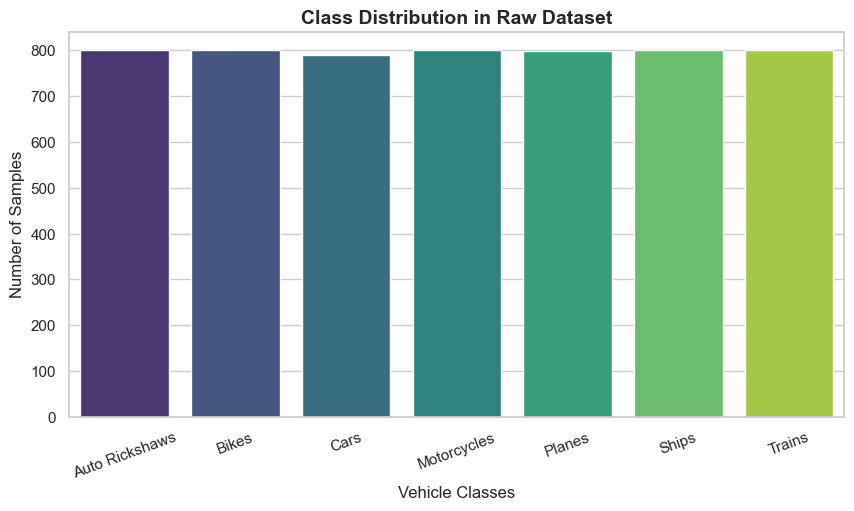

Samples per class: {'Auto Rickshaws': 800, 'Bikes': 800, 'Cars': 790, 'Motorcycles': 800, 'Planes': 799, 'Ships': 800, 'Trains': 800}


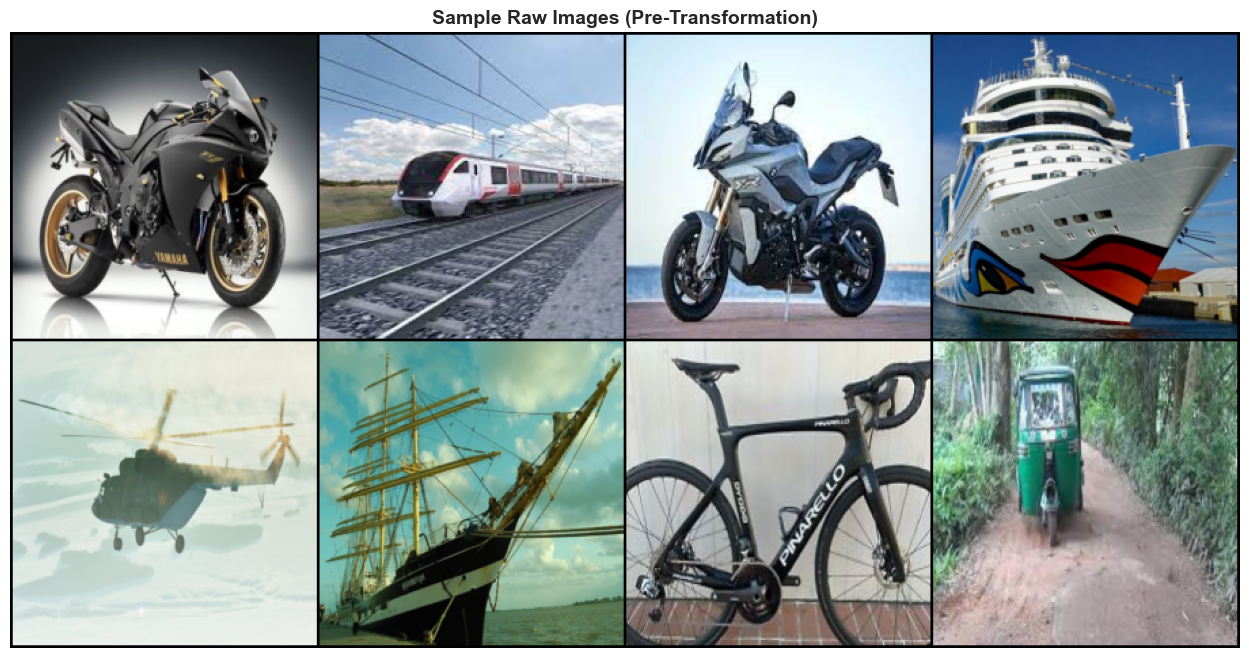

In [3]:
# Load raw dataset for exploratory analysis without complex augmentations
# We apply a simple resize strictly for unified visualization
transform_eda = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_eda = datasets.ImageFolder(root=DATA_DIR, transform=transform_eda)
class_names = dataset_eda.classes
num_classes = len(class_names)

print("== Dataset Profile ==")
print(f"Total samples: {len(dataset_eda)}")
print(f"Detected {num_classes} classes: {class_names}\n")

# CRITICAL FAILSAVE: Prevent execution if the dataset hierarchy is incorrect
assert num_classes > 1, \
    "CRITICAL ERROR: Only 1 class detected. Ensure your DATA_DIR contains subfolders for each individual class (e.g., data/car, data/truck)."

# 2.1 Plot Class Distribution
targets_eda = dataset_eda.targets
class_counts = Counter(targets_eda)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
class_labels = [class_names[i] for i in range(num_classes)]
sns.barplot(
    x=class_labels,
    y=[class_counts[i] for i in range(num_classes)],
    hue=class_labels,
    palette="viridis",
    legend=False
)
plt.title("Class Distribution in Raw Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Classes")
plt.ylabel("Number of Samples")
plt.xticks(rotation=20)
plt.show()

print("Samples per class:", {class_names[i]: class_counts[i] for i in range(num_classes)})

# 2.2 Show a grid of raw images
loader_eda = DataLoader(dataset_eda, batch_size=8, shuffle=True)
images_eda, labels_eda = next(iter(loader_eda))

plt.figure(figsize=(16, 8))
out_eda = torchvision.utils.make_grid(images_eda, nrow=4)
# Permute dimensions from PyTorch (C, H, W) to Matplotlib (H, W, C)
plt.imshow(out_eda.permute(1, 2, 0))
plt.title("Sample Raw Images (Pre-Transformation)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

### 2.3 Duplicate Audit

Image datasets collected from the web frequently contain the same photo several times: identical files, or resized and re-compressed copies. If two copies land in different splits, the test set contains images the model has effectively already seen, and the metrics become optimistic.

Each image is fingerprinted with a perceptual difference hash (dHash), which is robust to resizing and re-encoding. Images sharing a fingerprint are grouped and only one representative per group is kept **before** splitting, so no photo can appear on both sides of the train / test boundary.

In [4]:
def perceptual_hash(path, size=8):
    # Difference hash (dHash): compares adjacent pixels of a tiny grayscale thumbnail,
    # so resized or re-compressed copies of the same photo share the same fingerprint
    with Image.open(path) as img:
        gray = np.asarray(img.convert("L").resize((size + 1, size), Image.BILINEAR), dtype=np.int16)
    return np.packbits(gray[:, 1:] > gray[:, :-1]).tobytes()

hash_groups = {}
for idx, (path, _) in enumerate(dataset_eda.samples):
    hash_groups.setdefault(perceptual_hash(path), []).append(idx)

duplicate_groups = [g for g in hash_groups.values() if len(g) > 1]
cross_class_groups = [g for g in duplicate_groups if len({dataset_eda.targets[i] for i in g}) > 1]

# Keep a single representative per fingerprint
unique_idx = sorted(g[0] for g in hash_groups.values())
unique_counts = Counter(dataset_eda.targets[i] for i in unique_idx)

print("== Duplicate Audit ==")
print(f"Duplicate groups found: {len(duplicate_groups)} ({sum(len(g) for g in duplicate_groups)} images involved)")
print(f"Groups spanning more than one class: {len(cross_class_groups)}")
print(f"Images removed: {len(dataset_eda) - len(unique_idx)} | Unique images kept: {len(unique_idx)}\n")

df_dedup = pd.DataFrame({
    'Raw': [class_counts[i] for i in range(num_classes)],
    'Unique': [unique_counts[i] for i in range(num_classes)],
}, index=class_names)
df_dedup['Removed'] = df_dedup['Raw'] - df_dedup['Unique']
display(df_dedup)

== Duplicate Audit ==
Duplicate groups found: 162 (341 images involved)
Groups spanning more than one class: 0
Images removed: 179 | Unique images kept: 5410



,Raw,Unique,Removed
Auto Rickshaws,800,677,123
Bikes,800,787,13
Cars,790,781,9
Motorcycles,800,788,12
Planes,799,787,12
Ships,800,795,5
Trains,800,795,5


---
## 3. Data Processing Pipeline & Class Balancing

Defining the optimal transformations. A resolution of 224x224 is standard and mandatory for architectures like the Vision Transformer (ViT).
The training pipeline applies random crops from a 256x256 image, so the evaluation pipeline uses the matching deterministic counterpart (resize to 256x256 + center crop to 224x224) to keep the object scale identical between training and evaluation.

The deduplicated data is split with a stratified 70% / 15% / 15% scheme (train / validation / test). The validation set drives early stopping and model selection; the test set is only used for the final report.

The EDA shows the dataset is nearly balanced (~800 images per class, with `Cars` slightly below). A `WeightedRandomSampler` is still kept as a safeguard, so the pipeline remains correct if the class distribution changes (e.g., new data or a different dataset).

In [5]:
# Hyperparameters definition for the benchmark context
BATCH_SIZE = 32
NUM_EPOCHS = 5 # Reduced epoch count for benchmarking purposes
LEARNING_RATE = 0.001

# Image normalization metrics based on ImageNet standards
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Training transformations (includes Data Augmentation for generalization)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

# Validation & Test transformations (Deterministic evaluation)
transform_val = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    normalize
])

# Dataset instantiation mapped to structural transformations
dataset_train_base = datasets.ImageFolder(root=DATA_DIR, transform=transform_train)
dataset_val_base = datasets.ImageFolder(root=DATA_DIR, transform=transform_val)

targets = dataset_train_base.targets
NUM_CLASSES = num_classes

# --- 3-Way Stratified Split (Train: 70%, Val: 15%, Test: 15%) on the deduplicated images ---
# 1. Split into Train (70%) and Temp (30%)
unique_targets = [targets[i] for i in unique_idx]
sss_main = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_rel_idx, temp_rel_idx = next(sss_main.split(np.zeros(len(unique_idx)), unique_targets))
train_idx = [unique_idx[i] for i in train_rel_idx]
temp_idx = [unique_idx[i] for i in temp_rel_idx]

# 2. Split Temp (30%) into Validation (15%) and Test (15%)
temp_targets = [targets[i] for i in temp_idx]
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_rel_idx, test_rel_idx = next(sss_val.split(np.zeros(len(temp_targets)), temp_targets))

# Map relative indices back to absolute dataset indices
val_idx = [temp_idx[i] for i in val_rel_idx]
test_idx = [temp_idx[i] for i in test_rel_idx]

train_dataset = Subset(dataset_train_base, train_idx)
val_dataset = Subset(dataset_val_base, val_idx)
test_dataset = Subset(dataset_val_base, test_idx) # Uses the deterministic transform_val

# --- Class Balancing Strategy ---
train_targets = [targets[i] for i in train_idx]
class_counts_train = Counter(train_targets)

# Calculate inverse weights for each class to penalize majority classes
total_train_samples = len(train_targets)
class_weights = {cls: total_train_samples / (NUM_CLASSES * count) for cls, count in class_counts_train.items()}
sample_weights = [class_weights[t] for t in train_targets]

# Instantiate the weighted sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoaders definition (Note: shuffle=False is mandatory when using a custom sampler)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples allocated: {len(train_dataset)}")
print(f"Validation samples allocated: {len(val_dataset)}")
print(f"Testing samples allocated: {len(test_dataset)}")
print(f"Calculated class weighting strategy: { {class_names[c]: round(w, 4) for c, w in sorted(class_weights.items())} }")

Training samples allocated: 3787
Validation samples allocated: 811
Testing samples allocated: 812
Calculated class weighting strategy: {'Auto Rickshaws': 1.1414, 'Bikes': 0.9819, 'Cars': 0.989, 'Motorcycles': 0.9801, 'Planes': 0.9819, 'Ships': 0.973, 'Trains': 0.973}


---
## 4. Transformation Effects Analysis (Post-Transformation)

Validating the visual output of the Data Augmentation pipeline. This step confirms that crops, rotations, and color jittering are maintaining the semantic integrity of the vehicles while forcing the model to learn invariant features.

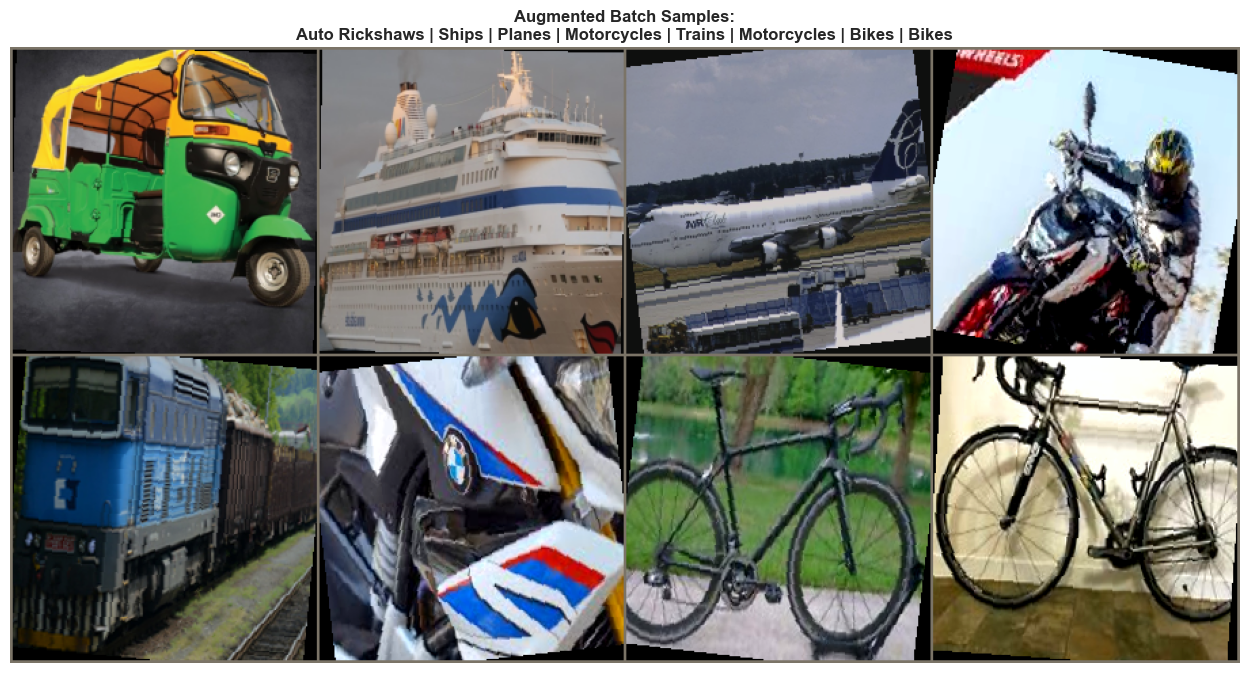

In [6]:
# Reverts the ImageNet normalization metrics strictly for Matplotlib visualization.
def unnormalize_and_show(img_tensor, labels):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    title_str = " | ".join([class_names[lbl] for lbl in labels])
    plt.title(f"Augmented Batch Samples:\n{title_str}", fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.show()

# Fetch an augmented batch from the training loader
inputs_aug, classes_aug = next(iter(train_loader))

out_aug = torchvision.utils.make_grid(inputs_aug[:8], nrow=4)
unnormalize_and_show(out_aug, classes_aug[:8].numpy())

---
## 5. Architectures Definition and Formulation

We structure a dynamic model factory function. This allows us to instantiate and modify the fully connected (classification) heads of 6 distinct architectures to map to our specific operational domain.

In [7]:
def build_model(model_name, num_classes):
    # Instantiates the requested architecture, initializes pre-trained weights, and adapts the final classification layer.
    if model_name == 'ResNet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'EfficientNet-B0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'MobileNetV3-Large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
        
    elif model_name == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    elif model_name == 'ConvNeXt-Tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
        
    elif model_name == 'ViT-B-16':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        
    else:
        raise ValueError(f"Architecture {model_name} not implemented.")
        
    return model.to(device)

---
## 6. Training and Evaluation Engine

A unified pipeline wrapper to compute standard performance metrics alongside computational temporal constraints.

In [8]:
def execute_training_pipeline(model_name, train_loader, val_loader, num_epochs=NUM_EPOCHS, patience=2):
    print(f"\n{'='*50}")
    print(f"Initializing Pipeline for Architecture: {model_name}")
    print(f"{'='*50}")

    model = build_model(model_name, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Early stopping trackers
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    # Start tracking computational time
    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation phase calculated per epoch for Early Stopping
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

        val_loss = val_loss / len(val_loader.dataset)

        # Early stopping logic evaluation
        if val_loss < best_val_loss:
            best_val_loss, epochs_no_improve = val_loss, 0
            # Create a deep copy of the weights to preserve the best version
            best_state = copy.deepcopy(model.state_dict())
            status = "Saved"
        else:
            epochs_no_improve += 1
            status = ""

        print(f"Epoch {epoch+1:2d} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} {status}")

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # Compute total execution time for training
    execution_time = time.time() - start_time
    # Restore the weights of the epoch with the lowest validation loss
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, execution_time


# Standardized inference function extracting predictions and probabilities.
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            out = model(inputs)
            probs = torch.softmax(out, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

---
## 7. Sequential Execution of the Benchmark

Iterating over the defined pool of models to compile comparative data. Each architecture is scored on the validation set (used to select the best model) and on the held-out test set (reported as the final, unbiased estimate).

In [9]:
architectures = [
    'ResNet18',
    'EfficientNet-B0',
    # Note: The remaining architectures are disabled to keep training time manageable in this benchmark phase.
    # Working initially with ResNet18 and EfficientNet-B0 validates the pipeline and provides representative comparative metrics.
    # Uncomment them to run the full six-model benchmark (ViT-B-16 usually needs a lower learning rate, e.g. 1e-4).
    #'MobileNetV3-Large',
    #'DenseNet121',
    #'ConvNeXt-Tiny',
    #'ViT-B-16'
]

benchmark_results = []
predictions_dict = {} # Dictionary to store probabilities for future ROC/AUC analysis

for arch_name in architectures:
    # 1. Train the architecture using Train & Validation sets
    trained_model, exec_time = execute_training_pipeline(arch_name, train_loader, val_loader)
    # 2. Validation metrics (used for model selection)
    y_true_val, y_pred_val, _ = get_predictions(trained_model, val_loader)
    # 3. Extract predictions using the best saved state ON THE UNSEEN TEST SET
    y_true, y_pred, y_probs = get_predictions(trained_model, test_loader)

    # 4. Save results
    benchmark_results.append({
        'Architecture': arch_name,
        'Val_F1_Score': f1_score(y_true_val, y_pred_val, average='macro'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_Score': f1_score(y_true, y_pred, average='macro'),
        'Execution_Time_sec': exec_time
    })

    predictions_dict[arch_name] = {'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}

    # Release GPU memory before instantiating the next architecture
    del trained_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Create analytical dataframe
df_results = pd.DataFrame(benchmark_results)
df_results.set_index('Architecture', inplace=True)


Initializing Pipeline for Architecture: ResNet18


Epoch  1 | Train Loss: 0.4502 | Val Loss: 0.2930 Saved


Epoch  2 | Train Loss: 0.3157 | Val Loss: 0.2390 Saved


Epoch  3 | Train Loss: 0.2381 | Val Loss: 0.2503 


Epoch  4 | Train Loss: 0.1972 | Val Loss: 0.1881 Saved


...

Epoch  1 | Train Loss: 0.3036 | Val Loss: 0.1814 Saved


Epoch  2 | Train Loss: 0.1517 | Val Loss: 0.0825 Saved


Epoch  3 | Train Loss: 0.0943 | Val Loss: 0.1088 


Epoch  4 | Train Loss: 0.1010 | Val Loss: 0.0580 Saved


Epoch  5 | Train Loss: 0.0702 | Val Loss: 0.0553 Saved


---
## 8. Evaluation, Visualizations and Trade-off Analysis

Displaying the compiled performance metrics to assess both the classification capabilities and the required computational budget.

,Val_F1_Score,Accuracy,F1_Score,Execution_Time_sec
Architecture,,,,
EfficientNet-B0,0.972781,0.969212,0.968958,328.419933
ResNet18,0.939342,0.938424,0.937770,322.529182


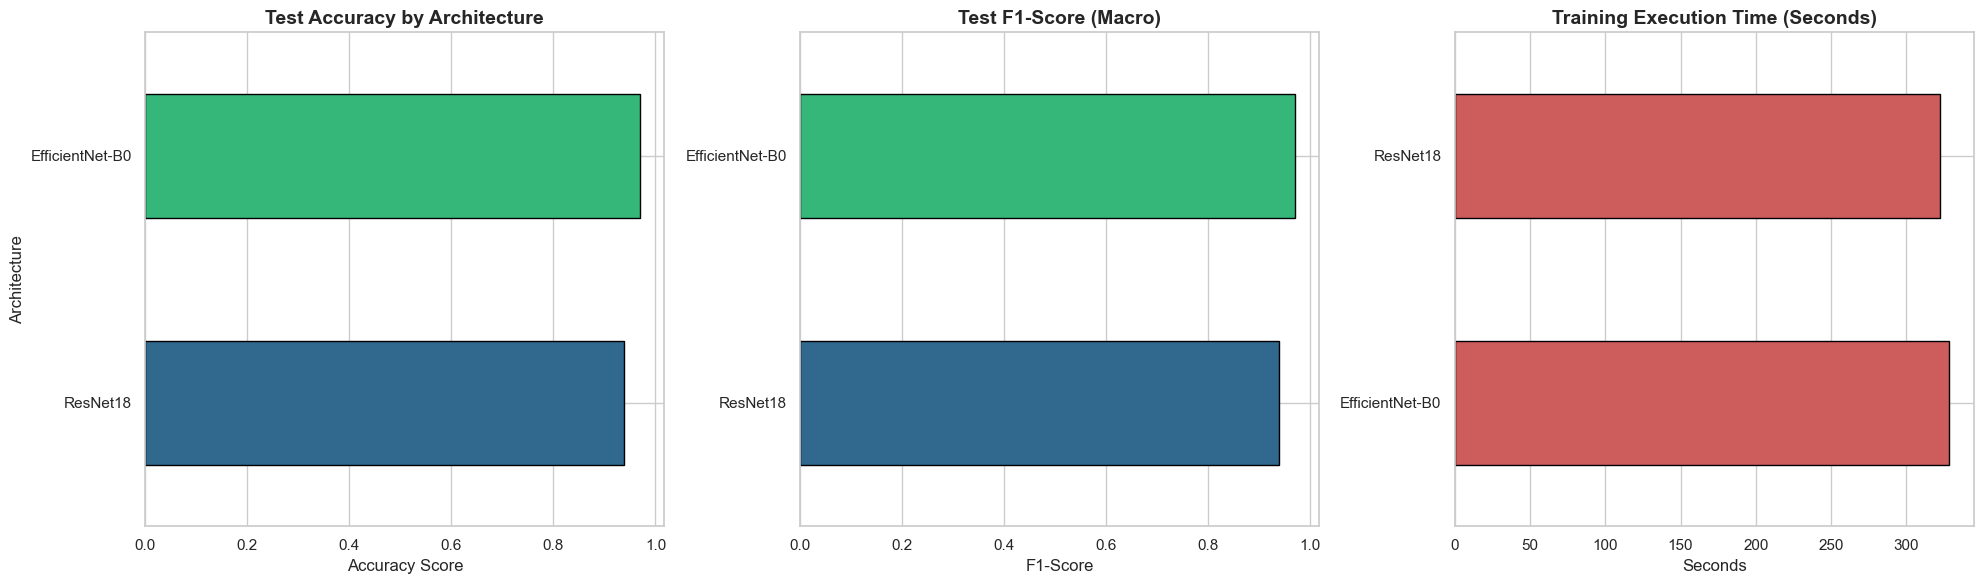


Deep-Dive Analysis for the Best Performing Architecture (by Validation F1): EfficientNet-B0

Classification Report (Evaluated on Test Set):
                precision    recall  f1-score   support

Auto Rickshaws       0.97      0.94      0.95       101
         Bikes       1.00      0.97      0.98       118
          Cars       0.95      0.97      0.96       117
   Motorcycles       0.95      0.98      0.97       118
        Planes       1.00      0.94      0.97       118
         Ships       0.93      1.00      0.96       120
        Trains       0.99      0.97      0.98       120

      accuracy                           0.97       812
     macro avg       0.97      0.97      0.97       812
  weighted avg       0.97      0.97      0.97       812





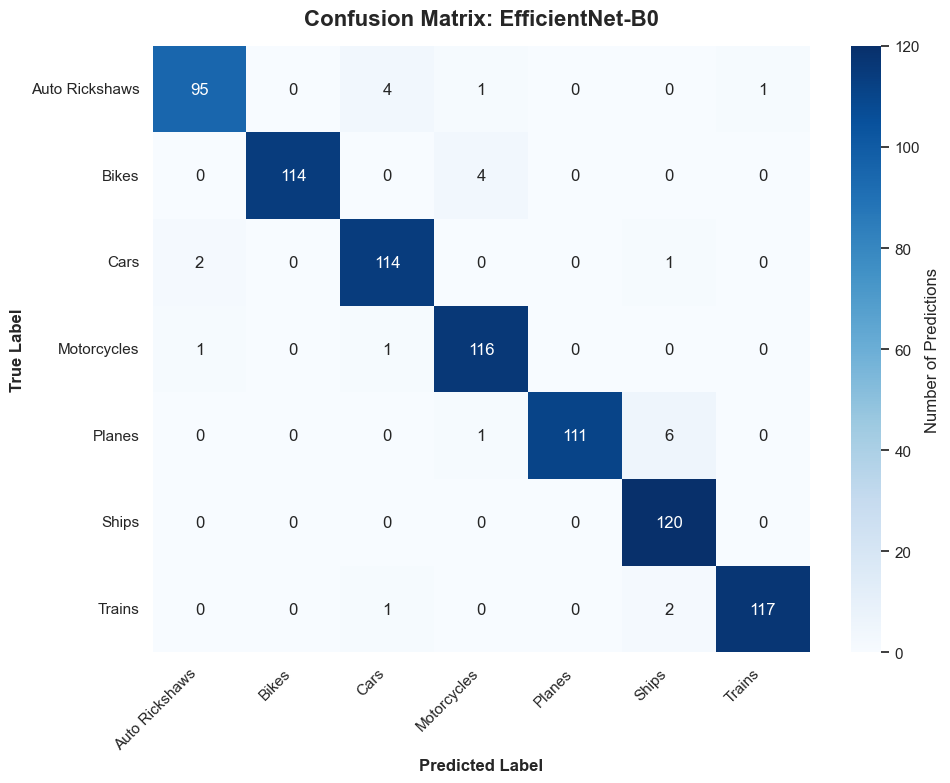

In [10]:
# ---------------------------------------------------------
# PART A: General Benchmark Overview (Accuracy, F1, Time)
# ---------------------------------------------------------
display(df_results.sort_values(by='F1_Score', ascending=False))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
color_palette = sns.color_palette("viridis", len(architectures))

# 1. Accuracy Plot
df_results['Accuracy'].sort_values().plot(
    kind='barh', ax=axes[0], color=color_palette, edgecolor='black')
axes[0].set_title('Test Accuracy by Architecture', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Accuracy Score')
axes[0].set_ylabel('Architecture')

# 2. F1-Score Plot
df_results['F1_Score'].sort_values().plot(
    kind='barh', ax=axes[1], color=color_palette, edgecolor='black')
axes[1].set_title('Test F1-Score (Macro)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].set_ylabel('')

# 3. Execution Time Plot
df_results['Execution_Time_sec'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[2], color='indianred', edgecolor='black')
axes[2].set_title('Training Execution Time (Seconds)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PART B: Deep-Dive Analysis for the Best Architecture
# ---------------------------------------------------------
# The best architecture is selected on the validation set to avoid optimistic bias on the test set
best_arch = df_results['Val_F1_Score'].idxmax()
print(f"\n{'='*70}")
print(f"Deep-Dive Analysis for the Best Performing Architecture (by Validation F1): {best_arch}")
print(f"{'='*70}\n")

y_true_best = predictions_dict[best_arch]['y_true']
y_pred_best = predictions_dict[best_arch]['y_pred']

# 1. Print Standard Classification Report
print("Classification Report (Evaluated on Test Set):")
print(classification_report(y_true_best, y_pred_best, target_names=class_names))
print("\n")

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_true_best, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Predictions'}, annot_kws={"size": 12})

plt.title(f'Confusion Matrix: {best_arch}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.1 Error Analysis: Misclassified Test Images

Looking at the actual images behind the errors shows whether the model fails on genuinely ambiguous pictures (unusual viewpoints, several vehicles in the frame, borderline class definitions) or on clear examples.

Misclassified test images: 25 of 812


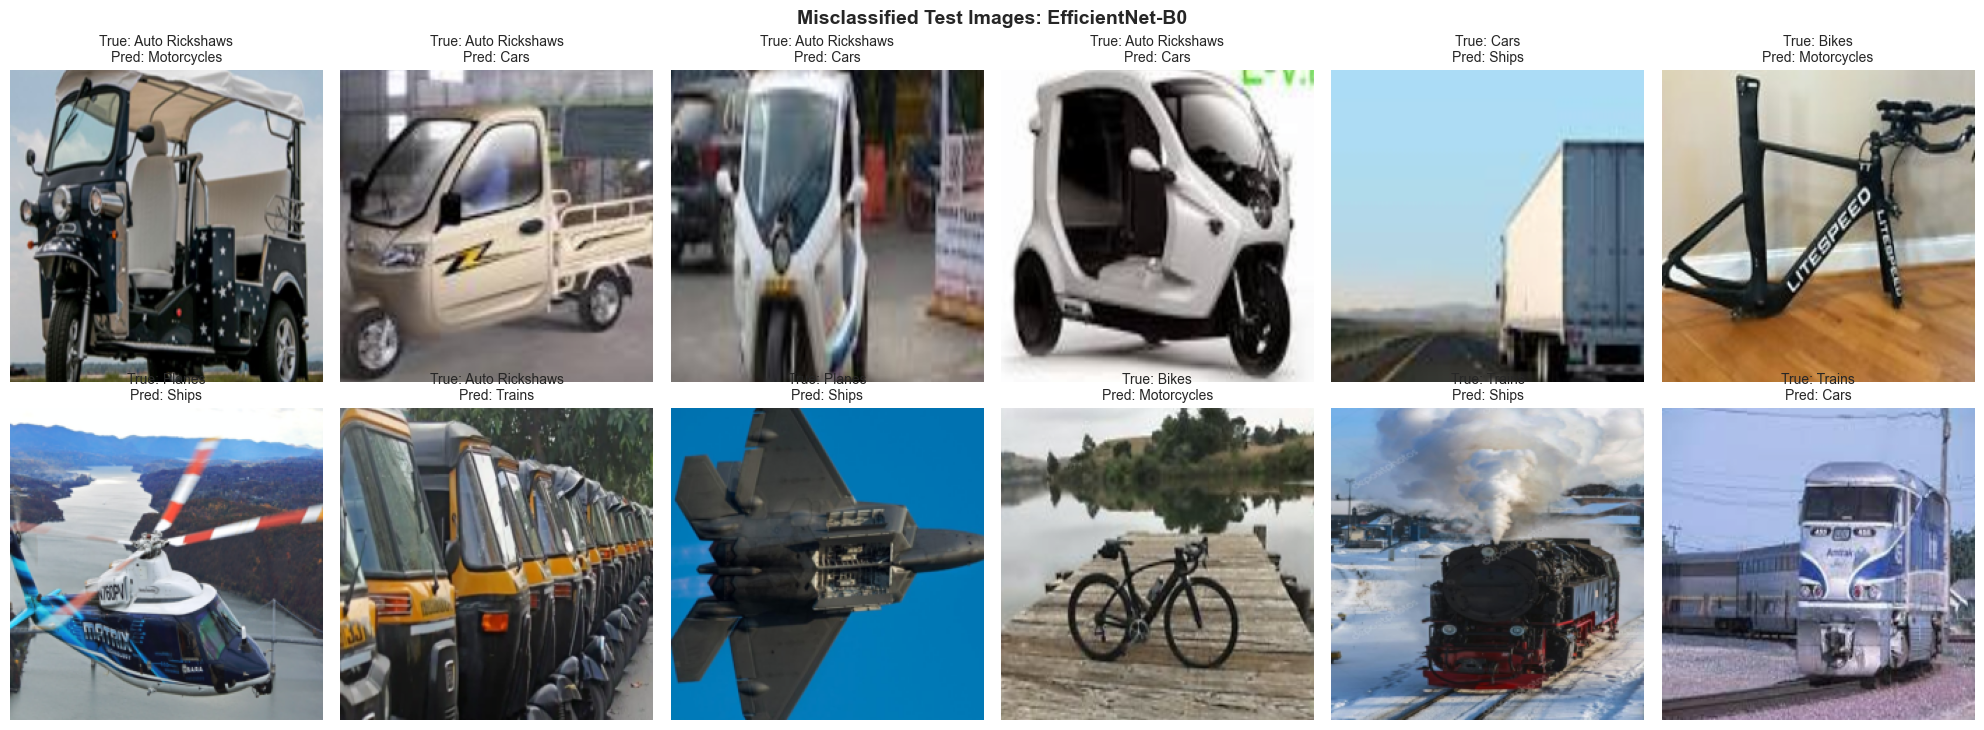

In [11]:
# Collect the test images misclassified by the best architecture
wrong = np.where(y_pred_best != y_true_best)[0]
print(f"Misclassified test images: {len(wrong)} of {len(y_true_best)}")

n_show = min(12, len(wrong))
fig, axes = plt.subplots(2, 6, figsize=(20, 7.5))
for ax, k in zip(axes.flat, wrong[:n_show]):
    img, _ = test_dataset[k]
    img = np.clip(img.numpy().transpose(1, 2, 0) * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
    ax.imshow(img)
    ax.set_title(f"True: {class_names[y_true_best[k]]}\nPred: {class_names[y_pred_best[k]]}", fontsize=10)
for ax in axes.flat:
    ax.axis("off")
plt.suptitle(f"Misclassified Test Images: {best_arch}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()